<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/04_train_all_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: Mount Drive and setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Clone repo
!git clone https://github.com/i10770e/xai-ids.git
%cd xai-ids

# Install any missing packages
!pip install imbalanced-learn

import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("✅ Setup complete!")

Mounted at /content/drive
Cloning into 'xai-ids'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'xai-ids'
/content
✅ Setup complete!


In [2]:
# ============================================
# CELL 2: Load the preprocessed data
# ============================================

data_path = '/content/drive/MyDrive/xai-ids/data/processed/nsl_kdd_processed.pkl'
data = joblib.load(data_path)

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

print(f"✅ Data loaded!")
print(f"   Train: {X_train.shape}, {y_train.shape}")
print(f"   Val: {X_val.shape}, {y_val.shape}")
print(f"   Test: {X_test.shape}, {y_test.shape}")

✅ Data loaded!
   Train: (110442, 41), (110442,)
   Val: (22676, 41), (22676,)
   Test: (22544, 41), (22544,)


In [3]:
# ============================================
# CELL 3: Setup results tracking
# ============================================

results = []

def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """Train model and return metrics"""

    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predict
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    # Calculate metrics
    metrics = {
        'model': model_name,
        'train_time': round(train_time, 2),
        'val_accuracy': round(accuracy_score(y_val, y_pred_val), 4),
        'val_precision': round(precision_score(y_val, y_pred_val, average='macro'), 4),
        'val_recall': round(recall_score(y_val, y_pred_val, average='macro'), 4),
        'val_f1': round(f1_score(y_val, y_pred_val, average='macro'), 4),
        'test_accuracy': round(accuracy_score(y_test, y_pred_test), 4),
        'test_precision': round(precision_score(y_test, y_pred_test, average='macro'), 4),
        'test_recall': round(recall_score(y_test, y_pred_test, average='macro'), 4),
        'test_f1': round(f1_score(y_test, y_pred_test, average='macro'), 4)
    }

    return model, metrics, y_pred_test

print("✅ Results tracker ready!")

✅ Results tracker ready!


In [4]:
# ============================================
# CELL 4: Train Naive Bayes
# ============================================
from sklearn.naive_bayes import GaussianNB

print("🔹 Training Naive Bayes...")
nb_model = GaussianNB()
nb_model, nb_metrics, nb_pred = evaluate_model(
    nb_model, "Naive Bayes",
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(nb_metrics)
print(f"   ✅ Validation F1: {nb_metrics['val_f1']}")
print(f"   ✅ Test F1: {nb_metrics['test_f1']}")

🔹 Training Naive Bayes...
   ✅ Validation F1: 0.8942
   ✅ Test F1: 0.7717


In [5]:
# ============================================
# CELL 5: Train KNN (find best k)
# ============================================
from sklearn.neighbors import KNeighborsClassifier

print("🔹 Training KNN (finding best k)...")
best_f1 = 0
best_k = None
knn_models = {}

for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    print(f"   k={k}: F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_k = k
        knn_models['best'] = knn

# Train best model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model, knn_metrics, knn_pred = evaluate_model(
    knn_model, f"KNN (k={best_k})",
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(knn_metrics)
print(f"✅ Best k={best_k} with F1: {knn_metrics['test_f1']}")

🔹 Training KNN (finding best k)...
   k=3: F1=0.9968
   k=5: F1=0.9961
   k=7: F1=0.9953
   k=9: F1=0.9952
   k=11: F1=0.9949
✅ Best k=3 with F1: 0.7618


In [6]:
# ============================================
# CELL 6: Train SVM
# ============================================
from sklearn.svm import SVC

print("🔹 Training SVM (this may take a few minutes)...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model, svm_metrics, svm_pred = evaluate_model(
    svm_model, "SVM (RBF)",
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(svm_metrics)
print(f"   ✅ Test F1: {svm_metrics['test_f1']}")

🔹 Training SVM (this may take a few minutes)...
   ✅ Test F1: 0.7813


In [7]:
# ============================================
# CELL 7: Train Random Forest
# ============================================
from sklearn.ensemble import RandomForestClassifier

print("🔹 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model, rf_metrics, rf_pred = evaluate_model(
    rf_model, "Random Forest",
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(rf_metrics)
print(f"   ✅ Test F1: {rf_metrics['test_f1']}")

🔹 Training Random Forest...
   ✅ Test F1: 0.7685


In [8]:
# ============================================
# CELL 8: Train 1D CNN
# ============================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("🔹 Building 1D CNN...")

def create_cnn(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Reshape((input_shape, 1)),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

cnn_model = create_cnn(X_train.shape[1])
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔹 Training CNN (this may take 5-10 minutes)...")
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Evaluate
y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype(int).flatten()
cnn_metrics = {
    'model': '1D CNN',
    'train_time': 'N/A',
    'val_accuracy': round(history.history['val_accuracy'][-1], 4),
    'val_precision': 0,  # Would need to calculate properly
    'val_recall': 0,
    'val_f1': 0,
    'test_accuracy': round(accuracy_score(y_test, y_pred_cnn), 4),
    'test_precision': round(precision_score(y_test, y_pred_cnn, average='macro'), 4),
    'test_recall': round(recall_score(y_test, y_pred_cnn, average='macro'), 4),
    'test_f1': round(f1_score(y_test, y_pred_cnn, average='macro'), 4)
}
results.append(cnn_metrics)
print(f"   ✅ Test F1: {cnn_metrics['test_f1']}")

# Save CNN model
cnn_model.save('/content/drive/MyDrive/xai-ids/results/models/cnn_model.h5')
print("✅ CNN model saved")

🔹 Building 1D CNN...
🔹 Training CNN (this may take 5-10 minutes)...
Epoch 1/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - accuracy: 0.9680 - loss: 0.0905 - val_accuracy: 0.9819 - val_loss: 0.0481
Epoch 2/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9862 - loss: 0.0375 - val_accuracy: 0.9859 - val_loss: 0.0442
Epoch 3/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9885 - loss: 0.0325 - val_accuracy: 0.9870 - val_loss: 0.0364
Epoch 4/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.9905 - loss: 0.0270 - val_accuracy: 0.9928 - val_loss: 0.0220
Epoch 5/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9908 - loss: 0.0259 - val_accuracy: 0.9892 - val_loss: 0.0323
Epoch 6/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.9917 - loss: 0.0231 - val_accuracy: 0.9904 - val_loss: 0.0325
Epoch 7/30
3452/3452 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9927 - loss: 0.0208 - val_accuracy: 0.9890 - val_loss: 0.0304
Epoch 8/

   ✅ Test F1: 0.7692
✅ CNN model saved


In [9]:
# ============================================
# CELL 9: Results comparison
# ============================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print("\n" + "="*80)
print("📊 MODEL COMPARISON RESULTS".center(80))
print("="*80)
print(results_df[['model', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'train_time']].to_string(index=False))
print("="*80)

# Save results
results_df.to_csv('/content/drive/MyDrive/xai-ids/results/metrics/model_comparison.csv', index=False)
print("\n✅ Results saved to Drive")


                           📊 MODEL COMPARISON RESULTS                           
        model  test_accuracy  test_precision  test_recall  test_f1 train_time
    SVM (RBF)         0.7821          0.8219       0.8060   0.7813     508.08
  Naive Bayes         0.7717          0.7917       0.7890   0.7717       0.16
       1D CNN         0.7694          0.7935       0.7882   0.7692        N/A
Random Forest         0.7695          0.8119       0.7941   0.7685      21.56
    KNN (k=3)         0.7632          0.8100       0.7890   0.7618       0.01

✅ Results saved to Drive


In [10]:
# ============================================
# CELL 10: Save the trained models
# ============================================

# Save sklearn models
joblib.dump(nb_model, '/content/drive/MyDrive/xai-ids/results/models/naive_bayes.pkl')
joblib.dump(knn_model, '/content/drive/MyDrive/xai-ids/results/models/knn.pkl')
joblib.dump(svm_model, '/content/drive/MyDrive/xai-ids/results/models/svm.pkl')
joblib.dump(rf_model, '/content/drive/MyDrive/xai-ids/results/models/random_forest.pkl')

print("✅ All models saved to Drive!")
print("\n📍 Model locations:")
print("   - /content/drive/MyDrive/xai-ids/results/models/")

✅ All models saved to Drive!

📍 Model locations:
   - /content/drive/MyDrive/xai-ids/results/models/


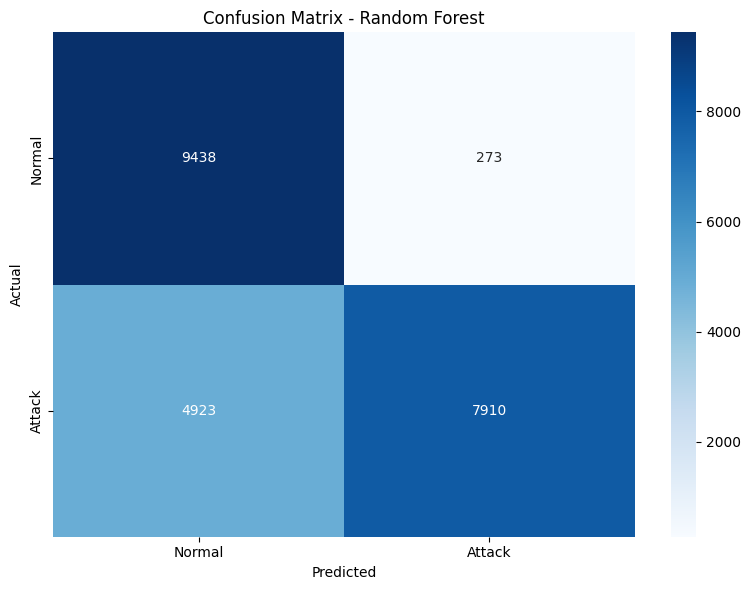

✅ Confusion matrix saved


In [11]:
# ============================================
# CELL 11: Confusion matrix for best model (Random Forest)
# ============================================

# Get best model's predictions
y_pred_best = rf_pred

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved")